In [50]:
#Cell 1: import
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import requests
import os
from gwosc.datasets import find_datasets
from gwosc import datasets
import time
import tarfile
import io
from astropy.io import fits
from ligo.skymap.io import read_sky_map
from ligo.skymap import postprocess

/opt/anaconda3/envs/bbh-visualization/lib/python3.11/site-packages/ligo/skymap/io/events/ligolw.py:26: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [ ]:
#Cell 2: getting all GWTC events
url = "https://gwosc.org/api/v2/catalogs/GWTC/events"
params = {"include-default-parameters": "true", "pagesize": 20}

all_events = []

while True:
    #Send a GET request to GWOSC with page number as a query parameter
    response = requests.get(url, params)
    #for page 1, this is the same thing as: https://gwosc.org/api/v2/catalogs/GWTC/events?include-default-parameters=true&pagesize=20&page=1
    
    # Parse the JSON body into a Python dictionary
    data = response.json()

    #grab event data, which is under "results," and add to running list
    all_events.extend(data["results"])

    # If there's no next page, stop looping
    if data["next"] is None:
        break

    # Otherwise advance to the next page
    url = data["next"] #next page url is under "next"
    params = {} #clearing because next url has all the parameters
    time.sleep(0.5)  #wait half a second between requests to not overload the server

print(f"\nTotal events fetched: {len(all_events)}") #for debugging


Total events fetched: 391


In [ ]:
#Cell 3: filtering for BBH events
def is_bbh(event):
    params = {p["name"]: p["best"] for p in event.get("default_parameters", [])} #return empty list if "default_parameters" is somehow missing
    #get the list under dictionary key "default paraemeters" in event, and we are traversing each item p in the list, which are dictionaries, and make take p["name"] the keys and p["best"] as values for this new dictionary params
    mass_one = params.get("mass_1_source", 0)  # returns 0 if missing, won't crash
    mass_two = params.get("mass_2_source", 0)  # returns 0 if missing, won't crash
    return mass_one > 3 and mass_two > 3

bbh_events = [e for e in all_events if is_bbh(e)] #filter
print(f"Total events: {len(all_events)}") #for debugging
print(f"BBH events: {len(bbh_events)}") #for debugging
for e in bbh_events[:5]:
    print(e["name"]) #for debugging

Total events: 391
BBH events: 273
GW250119_190238
GW250119_025138
GW250118_170523
GW250118_055802
GW250118_023225


In [ ]:
#Cell 4: Collect all events with skymaps

url = "https://gwosc.org/api/v2/event-versions?release=GWTC-1-confident%2CGWTC-2.1-confident%2CGWTC-3-confident%2CGWTC-4.0&lastver=true&include-default-parameters=true&format=json"
#this is the url for GWTC-4.0 cumulative. Replace this once GWTC-5.0 has skymaps

bbh_with_skymaps = []

while True:
    #GET request
    response = requests.get(url, {})
    # Parse the JSON body into a Python dictionary
    data = response.json()
    for event in data["results"]: #results is a dictionary
        if is_bbh(event):
            bbh_with_skymaps.append(event)
    if data["next"] is None:
        break
    url = data["next"]
    time.sleep(0.5)

print(f"Total bbh events with skymaps: {len(bbh_with_skymaps)}")

Total bbh events with skymaps: 167


In [35]:
#Cell 5: Get skymap URLS from bbh_with_skymaps
# GWTC-1: individual .fits.gz files on DCC, one per event
# GWTC-2.1 and GWTC-3: skymap URL is in the API under "label": "skymap" on the preferred result
# GWTC-4.0: single tar.gz on Zenodo containing all events

#GWTC-1 skymaps have been absorbed into GWTC-2.1
#GWTC1_SKYMAP_URL = "https://dcc.ligo.org/public/0157/P1800381/007/{name}_skymap.fits.gz"
GWTC4_SKYMAP_TAR = "https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Skymaps.tar.gz?download=1"

def get_parameters_with_retry(url, max_retries=3):
    for attempt in range(max_retries):
        response = requests.get(url, {})
        if response.status_code == 200 and response.text.strip():
            return response.json()
        print(f"    Attempt {attempt + 1} failed (status={response.status_code}), retrying in {2 ** attempt}s...")
        time.sleep(2 ** attempt)  # wait 1s, then 2s, then 4s
    return None  # all retries failed

skymap_urls = {}  # name -> url or tar info

for event in bbh_with_skymaps:
    name = event["name"]
    catalog = event["catalog"]

    # if catalog == "GWTC-1-confident":
    #     skymap_urls[name] = GWTC1_SKYMAP_URL.format(name=name)
    if catalog in ("GWTC-2.1-confident","GWTC-3-confident"):
        short_name = event["shortName"] 
        parameters_url = f"https://gwosc.org/api/v2/event-versions/{short_name}/parameters?format=json"

        data = get_parameters_with_retry(parameters_url)
        if data is None:
            print(f"  FAILED after all retries: {name}")
            continue

        found = False
        for result in data["results"]:
            if result["is_preferred"]:
                for link in result["links"]:
                    if link["label"] == "skymap":
                        skymap_urls[name] = link["url"]
                        found = True
        
        if not found:
            print(f"  WARNING: no skymap link found for {name} ({catalog})")

        time.sleep(0.3)

    elif catalog == "GWTC-4.0":
        skymap_urls[name] = GWTC4_SKYMAP_TAR

print(f"Skymap URLs found: {len(skymap_urls)} / {len(bbh_with_skymaps)}")
for name, url in list(skymap_urls.items())[:5]:
    print(f"  {name}: {url[:80]}...")


Skymap URLs found: 167 / 167
  GW240109_050431: https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...
  GW240107_013215: https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...
  GW240104_164932: https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...
  GW231231_154016: https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...
  GW231230_170116: https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...


In [ ]:
# Cell 6: Find skymap URLs
#.tar.gz is just a compressed folder

os.makedirs("skymaps", exist_ok=True)  # create skymaps folder if it doesn't exist

# find all unique tar URLs (GWTC-2.1 and GWTC-3 events may share the same tar)
unique_tars = {}  # tar_url -> list of event names that use it
gwtc1_events = {}  # event name -> individual URL (not a tar)

for event in bbh_with_skymaps:
    name = event["name"]
    catalog = event["catalog"]
    url = skymap_urls[name]

    if catalog == "GWTC-1-confident":
        gwtc1_events[name] = url  # individual file, handle separately
    else:
        if url not in unique_tars:
            unique_tars[url] = []
        unique_tars[url].append(name)  # group events by their tar URL

print(f"Individual GWTC-1 files to download: {len(gwtc1_events)}")
print(f"Unique tar archives to download: {len(unique_tars)}")
for url, names in unique_tars.items():
    print(f"  {url[:60]}...  ({len(names)} events)")

Individual GWTC-1 files to download: 0
Unique tar archives to download: 4
  https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214...  (84 events)
  https://zenodo.org/api/records/8177023/files/IGWN-GWTC3p0-v2...  (32 events)
  https://zenodo.org/api/records/6513631/files/IGWN-GWTC2p1-v2...  (41 events)
  https://zenodo.org/api/files/ecf41927-9275-47da-8b37-e299693...  (10 events)


In [42]:
#Cell 7: Download and extract skymaps for all 167 BBH events with the skymap URLs I just found in unique_tars
os.makedirs("skymaps", exist_ok=True) #create new dir on computer
for tar_url, event_names in unique_tars.items():
    print(f"\nDownloading tar for {len(event_names)} events...")
    print(f"  {tar_url[:80]}...") #for debugging

    # Stream to a temp file on disk instead of into RAM
    tar_path = "skymaps/_temp.tar.gz"
    with requests.get(tar_url, stream=True) as response:
        with open(tar_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8 * 1024 * 1024):  # 8MB chunks
                f.write(chunk)
    print(f"  Download complete, extracting...")

    with tarfile.open(tar_path, mode="r:gz") as tar:
        all_files = tar.getnames()
        for name in event_names:
            matches = [f for f in all_files if name in f and (f.endswith(".fits") or f.endswith(".fits.gz"))]
            ext = ".fits.gz" if matches and matches[0].endswith(".fits.gz") else ".fits"
            save_path = f"skymaps/{name}_skymap{ext}"
            if os.path.exists(save_path):
                print(f"  {name}: already exists, skipping")
                continue
            if len(matches) == 0:
                print(f"  {name}: no matching .fits file found in tar")
                continue
            if len(matches) > 1:
                print(f"  {name}: multiple matches, using first: {matches[0]}")
            member = tar.getmember(matches[0])
            with tar.extractfile(member) as f_in:
                with open(save_path, "wb") as f_out:
                    f_out.write(f_in.read())
                    print(f"  {name}: saved")
    os.remove(tar_path)  # clean up temp file
    print(f"  Temp file removed")

print("\nDone!")
print(f"Files in skymaps/: {len(os.listdir('skymaps'))}")


  https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...
  Download complete, extracting...
  GW240109_050431: multiple matches, using first: parameter_estimation/skymaps/IGWN-GWTC4p0-38214bd95_724-GW240109_050431-Mixed_Skymap_PEDataRelease.fits.gz
  GW240109_050431: saved
  GW240107_013215: multiple matches, using first: parameter_estimation/skymaps/IGWN-GWTC4p0-38214bd95_724-GW240107_013215-Mixed_Skymap_PEDataRelease.fits.gz
  GW240107_013215: saved
  GW240104_164932: multiple matches, using first: parameter_estimation/skymaps/IGWN-GWTC4p0-38214bd95_724-GW240104_164932-Mixed_Skymap_PEDataRelease.fits.gz
  GW240104_164932: saved
  GW231231_154016: multiple matches, using first: parameter_estimation/skymaps/IGWN-GWTC4p0-38214bd95_724-GW231231_154016-SEOBNRv5PHM_Skymap_PEDataRelease.fits.gz
  GW231231_154016: saved
  GW231230_170116: multiple matches, using first: parameter_estimation/skymaps/IGWN-GWTC4p0-38214bd95_724-GW231230_170116-SEOBNRv5PHM_Skymap_PED

In [43]:
os.remove("skymaps/_inspect.tar.gz")

In [ ]:
#Cell 8: Loading one skymap (GW150914) to inspect
# Peek inside the file first
with fits.open(test_file) as hdul:
    hdul.info()
    print(hdul[1].columns)

# Read and convert to a flat healpy map
skymap, metadata = read_sky_map(test_file, nest=True)

print(f"Number of pixels: {len(skymap)}")
print(f"NSIDE: {hp.npix2nside(len(skymap))}")
print(f"Sum (should be ~1.0): {skymap.sum():.6f}")

Filename: skymaps/GW150914_skymap.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     41   16896R x 5C   [K, D, D, D, D]   
ColDefs(
    name = 'UNIQ'; format = 'K'
    name = 'PROBDENSITY'; format = 'D'; unit = 'sr-1'
    name = 'DISTMU'; format = 'D'; unit = 'Mpc'
    name = 'DISTSIGMA'; format = 'D'; unit = 'Mpc'
    name = 'DISTNORM'; format = 'D'; unit = 'Mpc-2'
)
Number of pixels: 3145728
NSIDE: 512
Sum (should be ~1.0): 1.000000


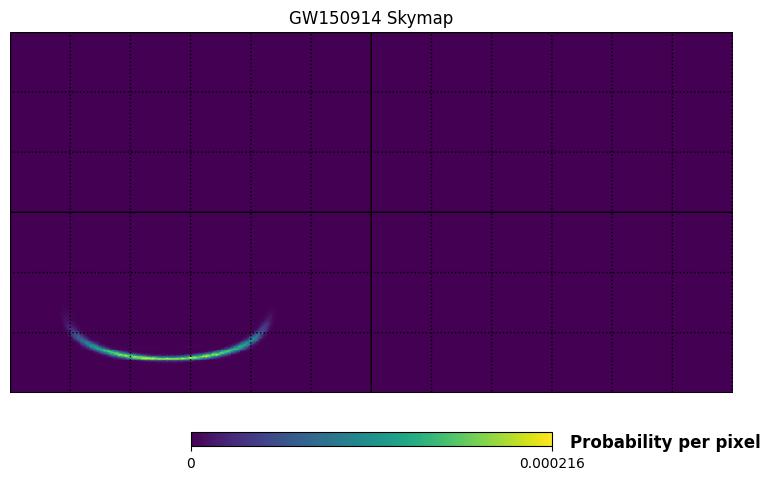

In [ ]:
#Cell 9: Plot a single skymap (GW150914) as equirectangular projection
# Convert from nested to ring ordering (required for mollview/cartview)
skymap_ring = hp.reorder(skymap, n2r=True)

# Equirectangular projection
hp.cartview(
    skymap_ring,
    title="GW150914 Skymap",
    unit="Probability per pixel",
    cmap="viridis",
    fig=1
)
hp.graticule()  # adds grid lines
plt.show()

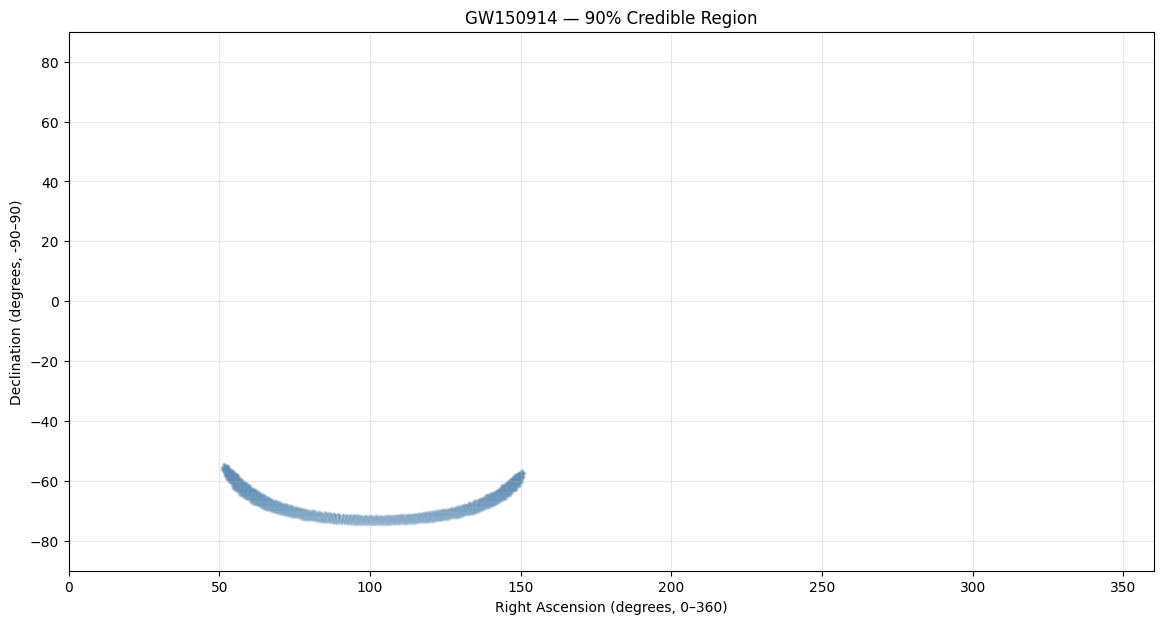

In [ ]:
#Cell 10: Compute and plot the 90% credible region contour for GW150914
# Sort pixels by probability, highest first
# Then find the minimum number of pixels that sum to 90% of total probability

sorted_indices = np.argsort(skymap_ring)[::-1]  
#returns the indices that would sort the array from lowest to highest. [::-1] reverses it so it's highest to lowest.
cumsum = np.cumsum(skymap_ring[sorted_indices])  #an array containing running total of probability (cumulative sums)
threshold = cumsum.searchsorted(0.90)  # how many pixels to reach 90%, ie the index of cumsum where we reach 0.9

# Make a binary map: 1 inside 90% region, 0 outside
confidence_map = np.zeros(len(skymap_ring)) #reates a new array of zeros, same length as the skymap.
confidence_map[sorted_indices[:threshold]] = 1.0 #make binary map where every pixel up to the threshold is set to 1.0

# Convert every pixel center to (ra, dec) coordinates to plot as scatter plot
nside = hp.npix2nside(len(confidence_map)) #Determines the HEALPix resolution level (NSIDE) from the total number of pixels.
npix = len(confidence_map) #total pixel count
theta, phi = hp.pix2ang(nside, np.arange(npix), nest=False) #Converts all pixel indices to spherical coordinates: theta (colatitude) and phi (longitude)

# healpy uses physics convention: theta=colatitude (0=north pole), phi=longitude
#Convert from HEALPix's physics convention to astronomical coordinates (RA/Dec).
dec = 90 - np.degrees(theta)  # convert to declination (-90 to 90)
ra = np.degrees(phi)           # convert to RA (0 to 360)

# Only plot pixels inside the 90% region
inside = confidence_map == 1.0 #Create a boolean mask selecting only pixels inside the 90% region (value = 1.0).
plt.figure(figsize=(14, 7))
plt.scatter(ra[inside], dec[inside], s=0.01, c="steelblue", alpha=0.5) #Plots only the credible region pixels as points on an RA/Dec grid.
plt.xlabel("Right Ascension (degrees, 0–360)")
plt.ylabel("Declination (degrees, -90–90)")
plt.title("GW150914 — 90% Credible Region")
#Sets axis ranges to match standard astronomical coordinates.
plt.xlim(0, 360)
plt.ylim(-90, 90)
plt.grid(True, alpha=0.3)
plt.show()
# # Plot it
# hp.cartview(
#     confidence_map,
#     title="GW150914 — 90% Credible Region",
#     cmap="Blues",
#     fig=1
# )
# hp.graticule()
# plt.show()